# EDA churn vs not churn - phần Tùng

Notebook này chạy bằng uv env `data vis/.venv` qua kernel `Python (data-vis uv)`.

Workflow được căn theo repo tham chiếu `group_churn_workflow`:

1. Load dữ liệu churn/stayed.
2. Tạo trạng thái churn dạng nhị phân giống bước Power BI transform.
3. Tạo nhóm/bin tham chiếu cho từng feature giống cách repo tạo age group, tenure group, monthly charge range.
4. Với từng feature: thống kê riêng `Churn` và `Not churn`, tính số khách theo nhóm, total customer, total churn, churn rate.
5. Dùng correlation với biến churn để kết luận feature nghiêng về churn hay not churn.

Feature phần Tùng:

- `customer_satisfaction`
- `num_complaints`
- `num_service_calls`
- `late_payments`
- `avg_monthly_gb`
- `days_since_last_interaction`
- `credit_score`

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.0)

BASE = Path.cwd()
REFERENCE_REPO = BASE / "group_churn_workflow"
OUTPUT_DIR = BASE / "eda_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

FEATURES = [
    "customer_satisfaction",
    "num_complaints",
    "num_service_calls",
    "late_payments",
    "avg_monthly_gb",
    "days_since_last_interaction",
    "credit_score",
]

churn = pd.read_csv(BASE / "customer_churn_only.csv", usecols=FEATURES)
not_churn = pd.read_csv(BASE / "customer_not_churn.csv", usecols=FEATURES)

churn["Customer_Status"] = "Churn"
not_churn["Customer_Status"] = "Not churn"
churn["churn"] = 1
not_churn["churn"] = 0

df = pd.concat([churn, not_churn], ignore_index=True)

print(f"Reference repo exists: {REFERENCE_REPO.exists()} - {REFERENCE_REPO}")
print(f"Churn rows: {len(churn):,}")
print(f"Not churn rows: {len(not_churn):,}")
print(f"Total customers: {len(df):,}")
print(f"Total churn: {df['churn'].sum():,}")
print(f"Overall churn rate: {df['churn'].mean() * 100:.2f}%")
print("Missing values:")
print(df[FEATURES].isna().sum())

Reference repo exists: True - /home/tung/2025.2-Data-Visualization/data vis/group_churn_workflow
Churn rows: 83,362
Not churn rows: 757,403
Total customers: 840,765
Total churn: 83,362
Overall churn rate: 9.92%
Missing values:
customer_satisfaction          0
num_complaints                 0
num_service_calls              0
late_payments                  0
avg_monthly_gb                 0
days_since_last_interaction    0
credit_score                   0
dtype: int64


In [2]:
FEATURE_CONFIG = {
    "customer_satisfaction": {
        "title": "Customer satisfaction",
        "bins": [0, 3, 6, 9],
        "labels": ["Low 1-3", "Medium 4-6", "High 7-9"],
        "xlabel": "Satisfaction group",
        "kind": "ordinal",
    },
    "num_complaints": {
        "title": "Number of complaints",
        "bins": [-0.1, 0, 1, 2, np.inf],
        "labels": ["0", "1", "2", "3+"],
        "xlabel": "Complaint group",
        "kind": "count",
    },
    "num_service_calls": {
        "title": "Number of service calls",
        "bins": [-0.1, 0, 1, 2, 4, np.inf],
        "labels": ["0", "1", "2", "3-4", "5+"],
        "xlabel": "Service call group",
        "kind": "count",
    },
    "late_payments": {
        "title": "Late payments",
        "bins": [-0.1, 0, 1, 2, np.inf],
        "labels": ["0", "1", "2", "3+"],
        "xlabel": "Late payment group",
        "kind": "count",
    },
    "avg_monthly_gb": {
        "title": "Average monthly GB",
        "bins": [-0.001, 0, 10, 25, 50, 100, np.inf],
        "labels": ["0", "0-10", "10-25", "25-50", "50-100", "100+"],
        "xlabel": "Average monthly GB group",
        "kind": "continuous",
    },
    "days_since_last_interaction": {
        "title": "Days since last interaction",
        "bins": [0, 7, 14, 30, 60, 90, 180, 365],
        "labels": ["1-7", "8-14", "15-30", "31-60", "61-90", "91-180", "181-365"],
        "xlabel": "Days since last interaction group",
        "kind": "continuous",
    },
    "credit_score": {
        "title": "Credit score",
        "bins": [299, 600, 700, 800, 850],
        "labels": ["300-599", "600-699", "700-799", "800-850"],
        "xlabel": "Credit score group",
        "kind": "continuous",
    },
}

for feature, cfg in FEATURE_CONFIG.items():
    group_col = f"{feature}_group"
    df[group_col] = pd.cut(
        df[feature],
        bins=cfg["bins"],
        labels=cfg["labels"],
        include_lowest=True,
        right=True,
    )

print("Created feature groups:")
for feature, cfg in FEATURE_CONFIG.items():
    print(feature, "->", cfg["labels"])

Created feature groups:
customer_satisfaction -> ['Low 1-3', 'Medium 4-6', 'High 7-9']
num_complaints -> ['0', '1', '2', '3+']
num_service_calls -> ['0', '1', '2', '3-4', '5+']
late_payments -> ['0', '1', '2', '3+']
avg_monthly_gb -> ['0', '0-10', '10-25', '25-50', '50-100', '100+']
days_since_last_interaction -> ['1-7', '8-14', '15-30', '31-60', '61-90', '91-180', '181-365']
credit_score -> ['300-599', '600-699', '700-799', '800-850']


In [3]:
segment_stats = {}
group_tables = {}
corr_with_churn = df[FEATURES + ["churn"]].corr(numeric_only=True)["churn"].drop("churn")

for feature, cfg in FEATURE_CONFIG.items():
    segment_stats[feature] = (
        df.groupby("Customer_Status")[feature]
        .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
        .round(2)
    )

    group_col = f"{feature}_group"
    table = (
        df.groupby([group_col, "Customer_Status"], observed=False)
        .size()
        .unstack(fill_value=0)
    )
    for col in ["Not churn", "Churn"]:
        if col not in table.columns:
            table[col] = 0
    table = table[["Not churn", "Churn"]]
    table["Total"] = table["Not churn"] + table["Churn"]
    table["Churn rate (%)"] = (table["Churn"] / table["Total"] * 100).round(2)
    group_tables[feature] = table

print("Correlation with churn, sorted by absolute strength:")
print(corr_with_churn.sort_values(key=lambda s: s.abs(), ascending=False).round(5).to_string())

for feature in FEATURES:
    print("\n" + "=" * 96)
    print(feature)
    print("Segment stats:")
    print(segment_stats[feature].to_string())
    print("\nGroup table:")
    print(group_tables[feature].to_string())

Correlation with churn, sorted by absolute strength:
customer_satisfaction         -0.08457
num_complaints                 0.08018
num_service_calls              0.07708
late_payments                  0.04812
avg_monthly_gb                -0.00585
credit_score                  -0.00133
days_since_last_interaction    0.00126

customer_satisfaction
Segment stats:
                    count  mean   std  min  25%  50%  75%  90%  95%  max
Customer_Status                                                         
Churn             83362.0  5.57  2.49  1.0  4.0  6.0  8.0  9.0  9.0  9.0
Not churn        757403.0  6.22  2.30  1.0  5.0  7.0  8.0  9.0  9.0  9.0

Group table:
Customer_Status              Not churn  Churn   Total  Churn rate (%)
customer_satisfaction_group                                          
Low 1-3                         113885  20820  134705           15.46
Medium 4-6                      249370  28040  277410           10.11
High 7-9                        394148  34502  428

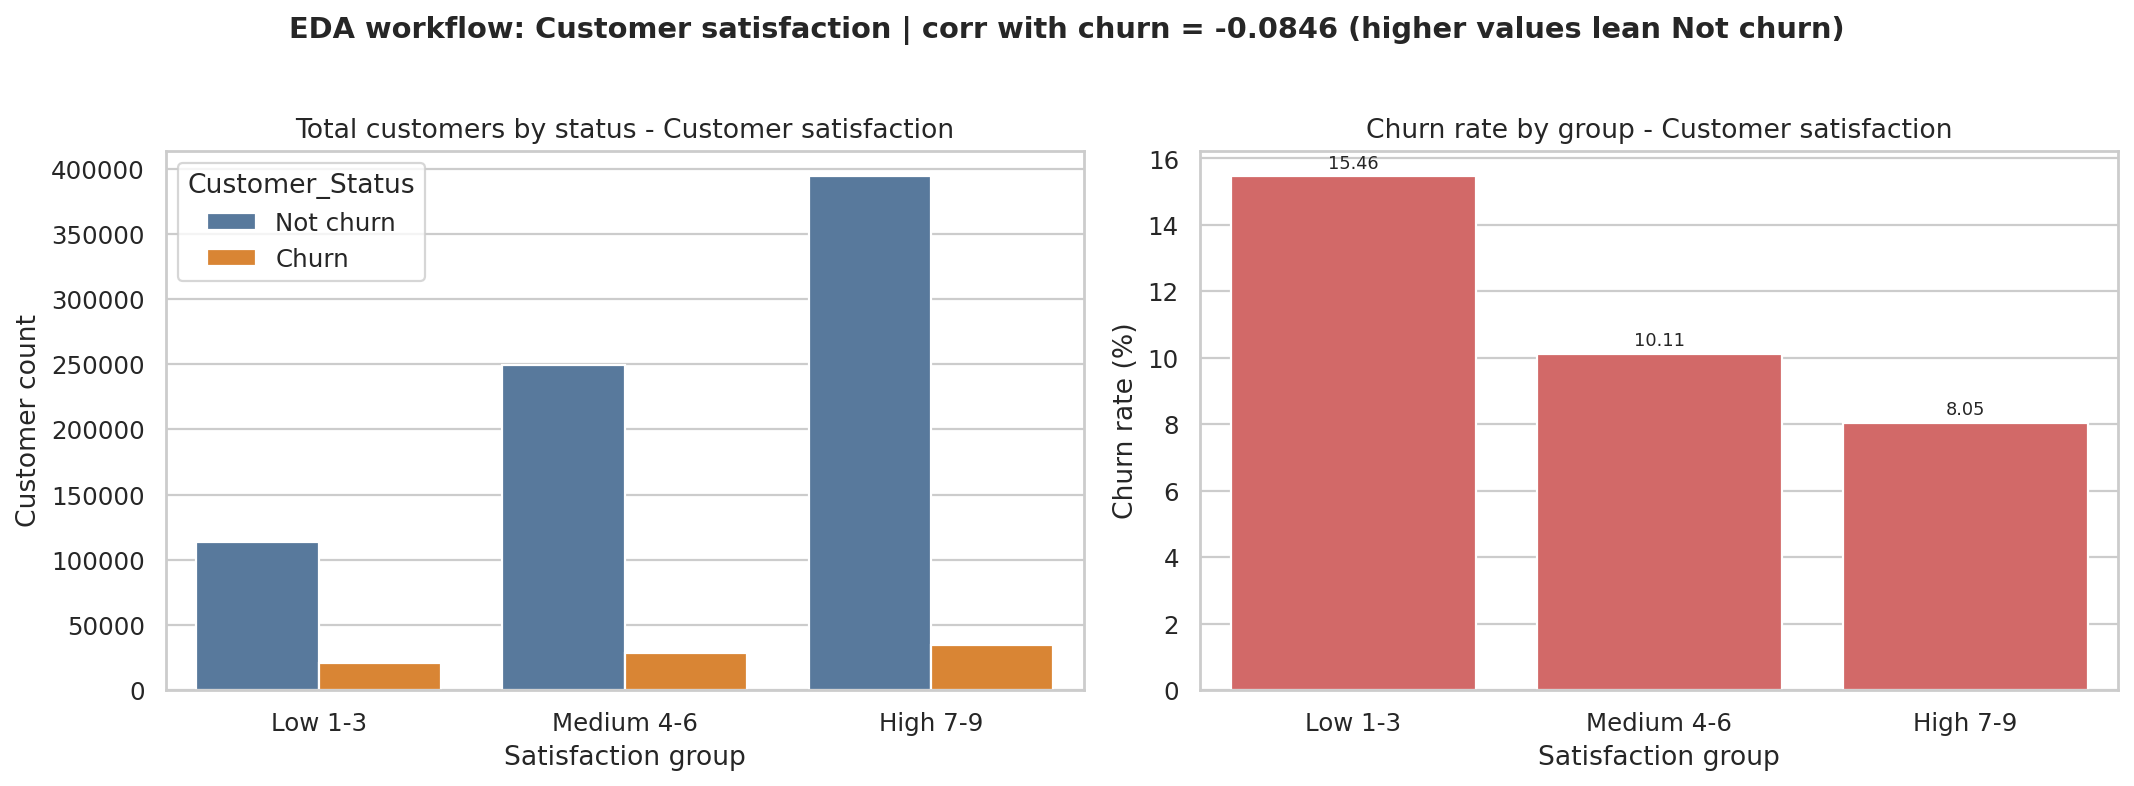

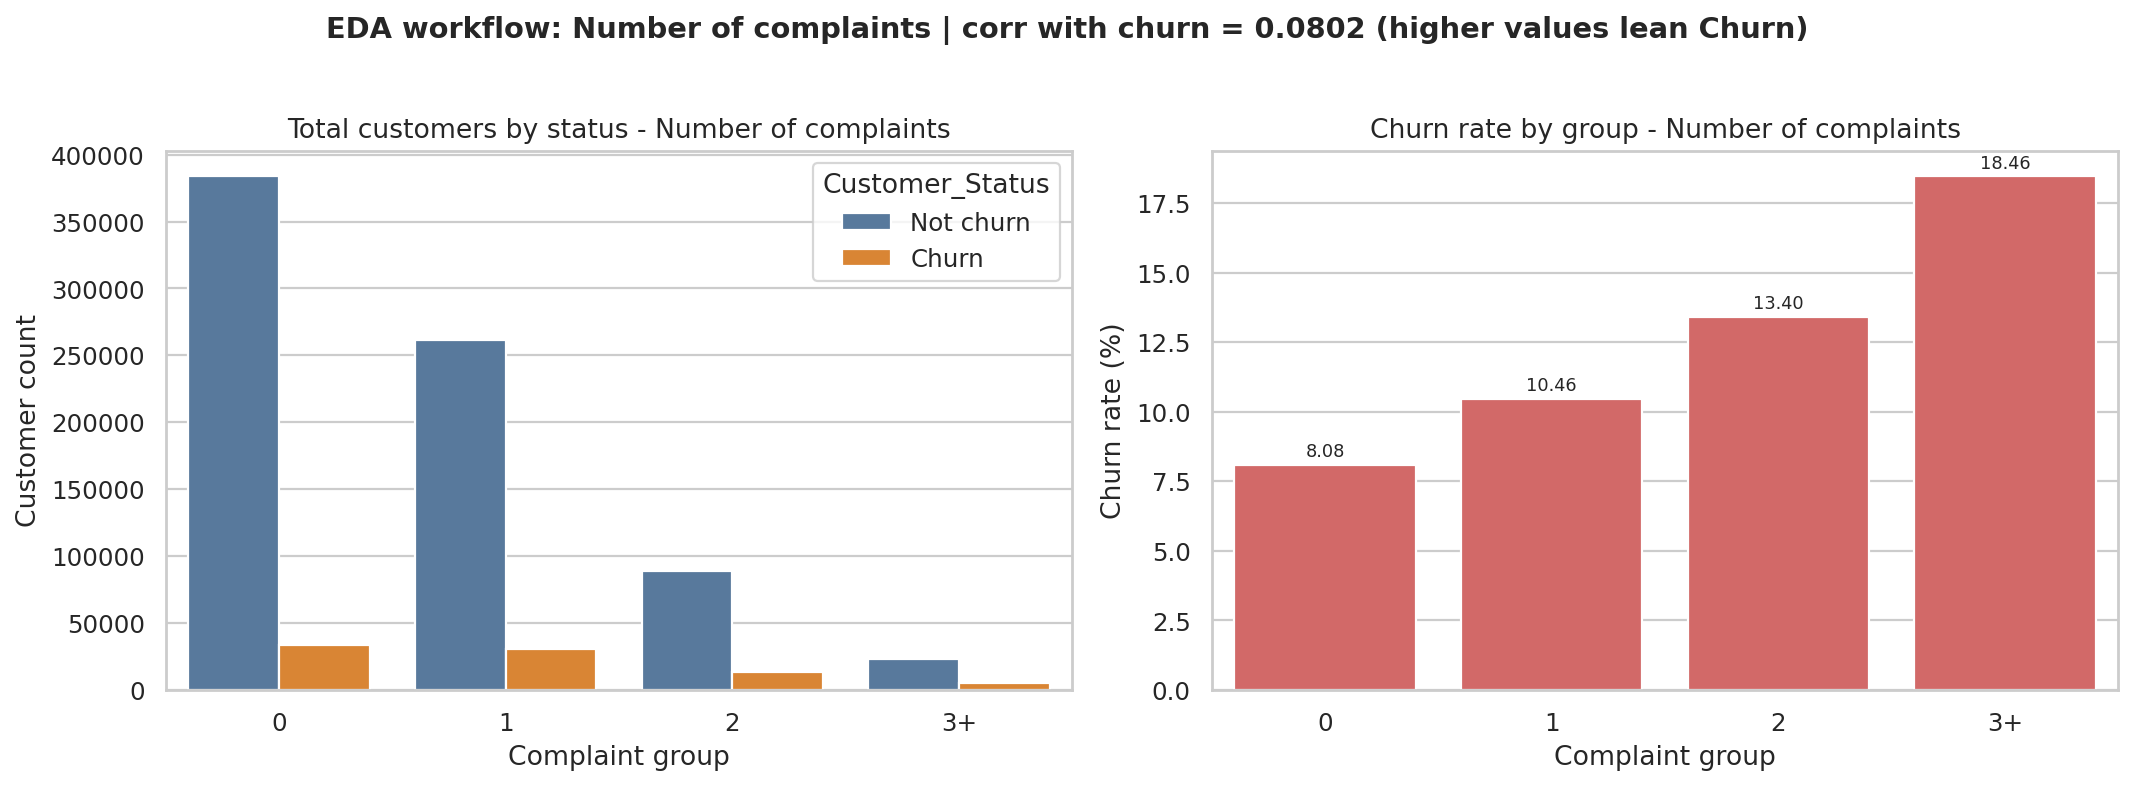

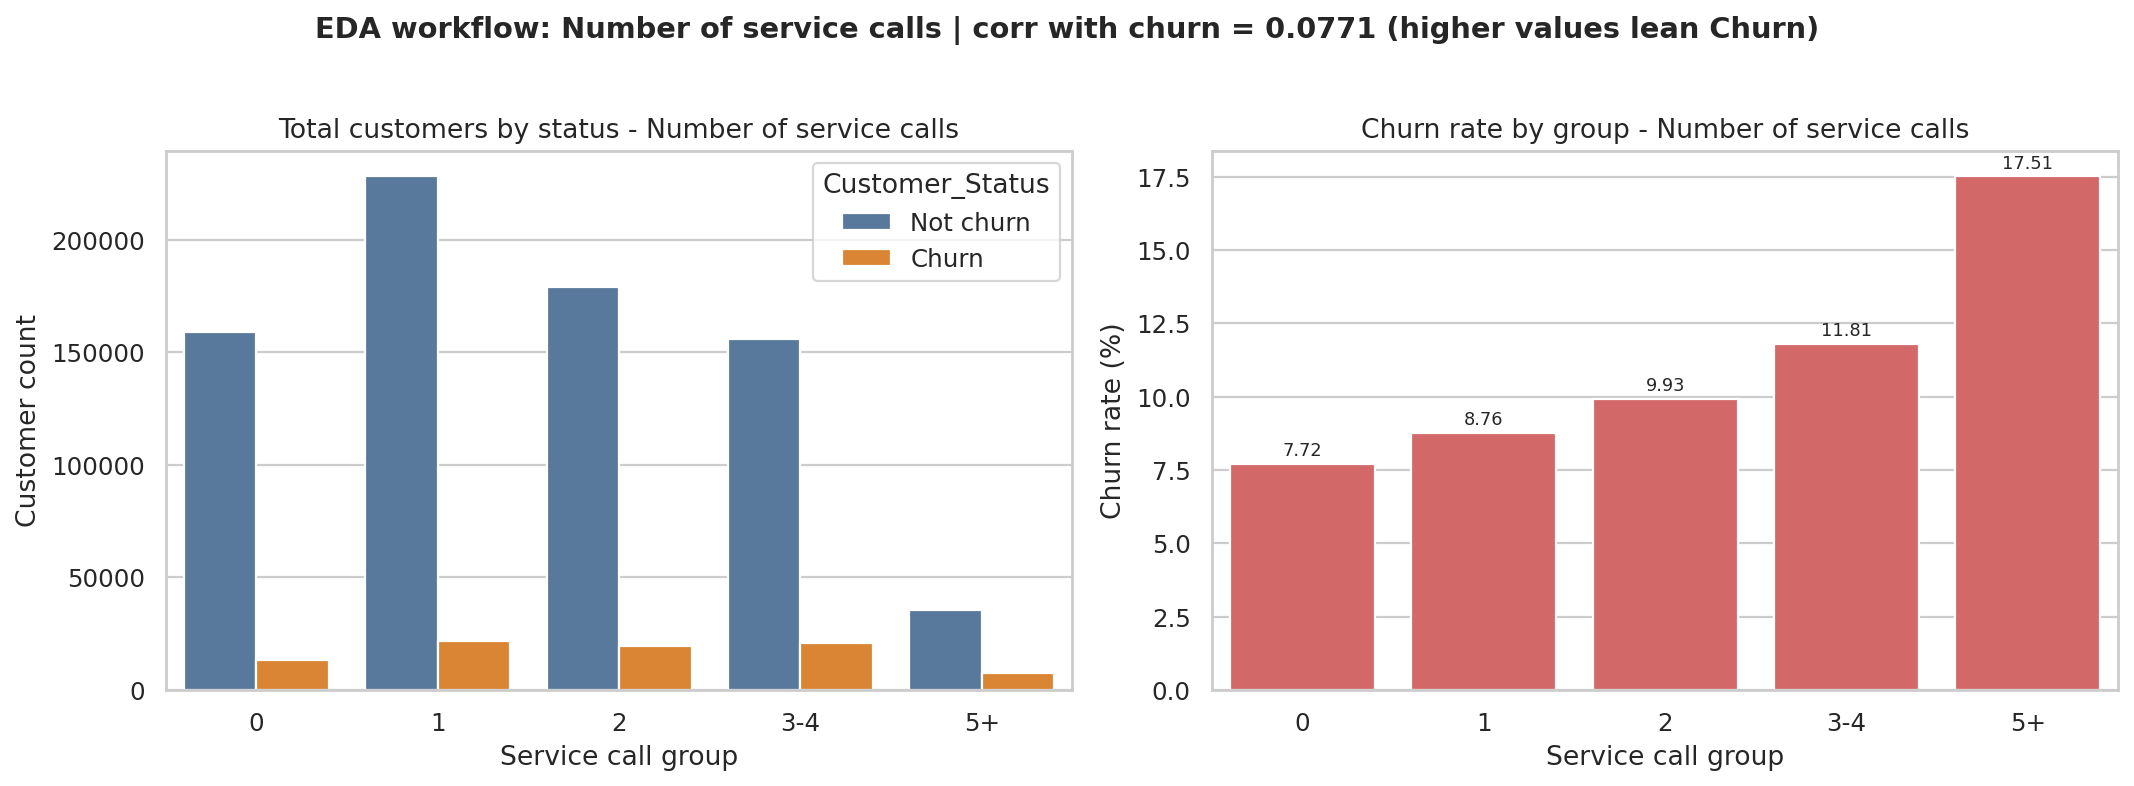

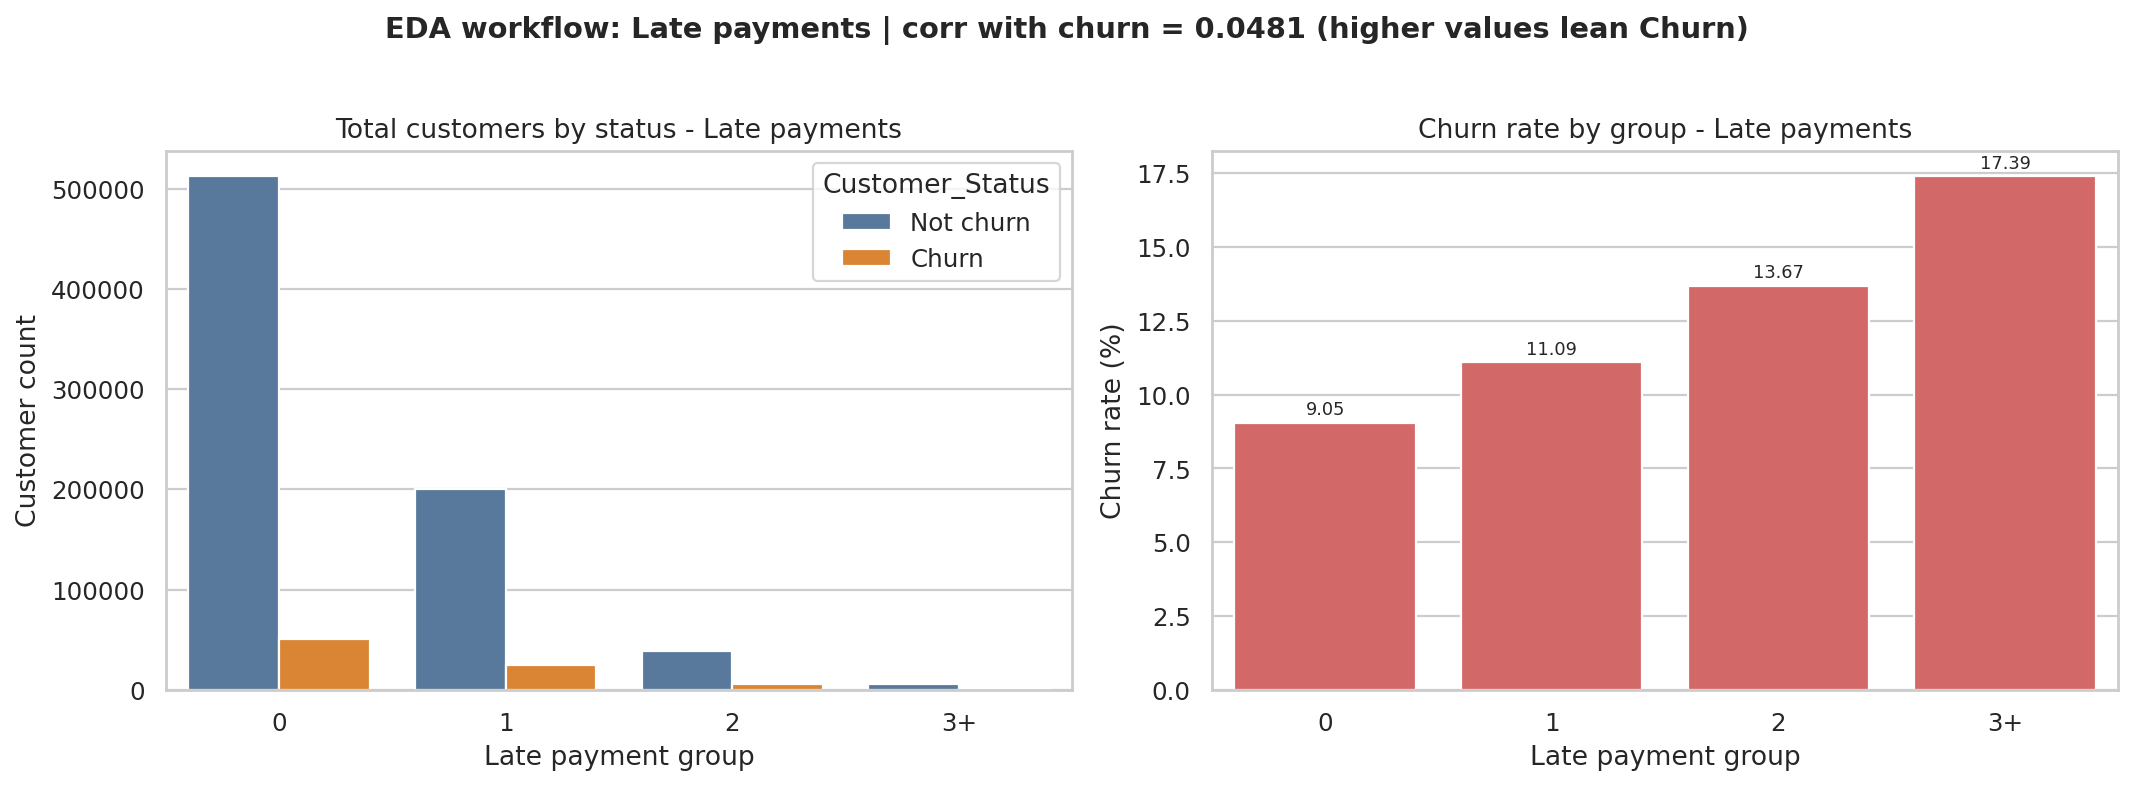

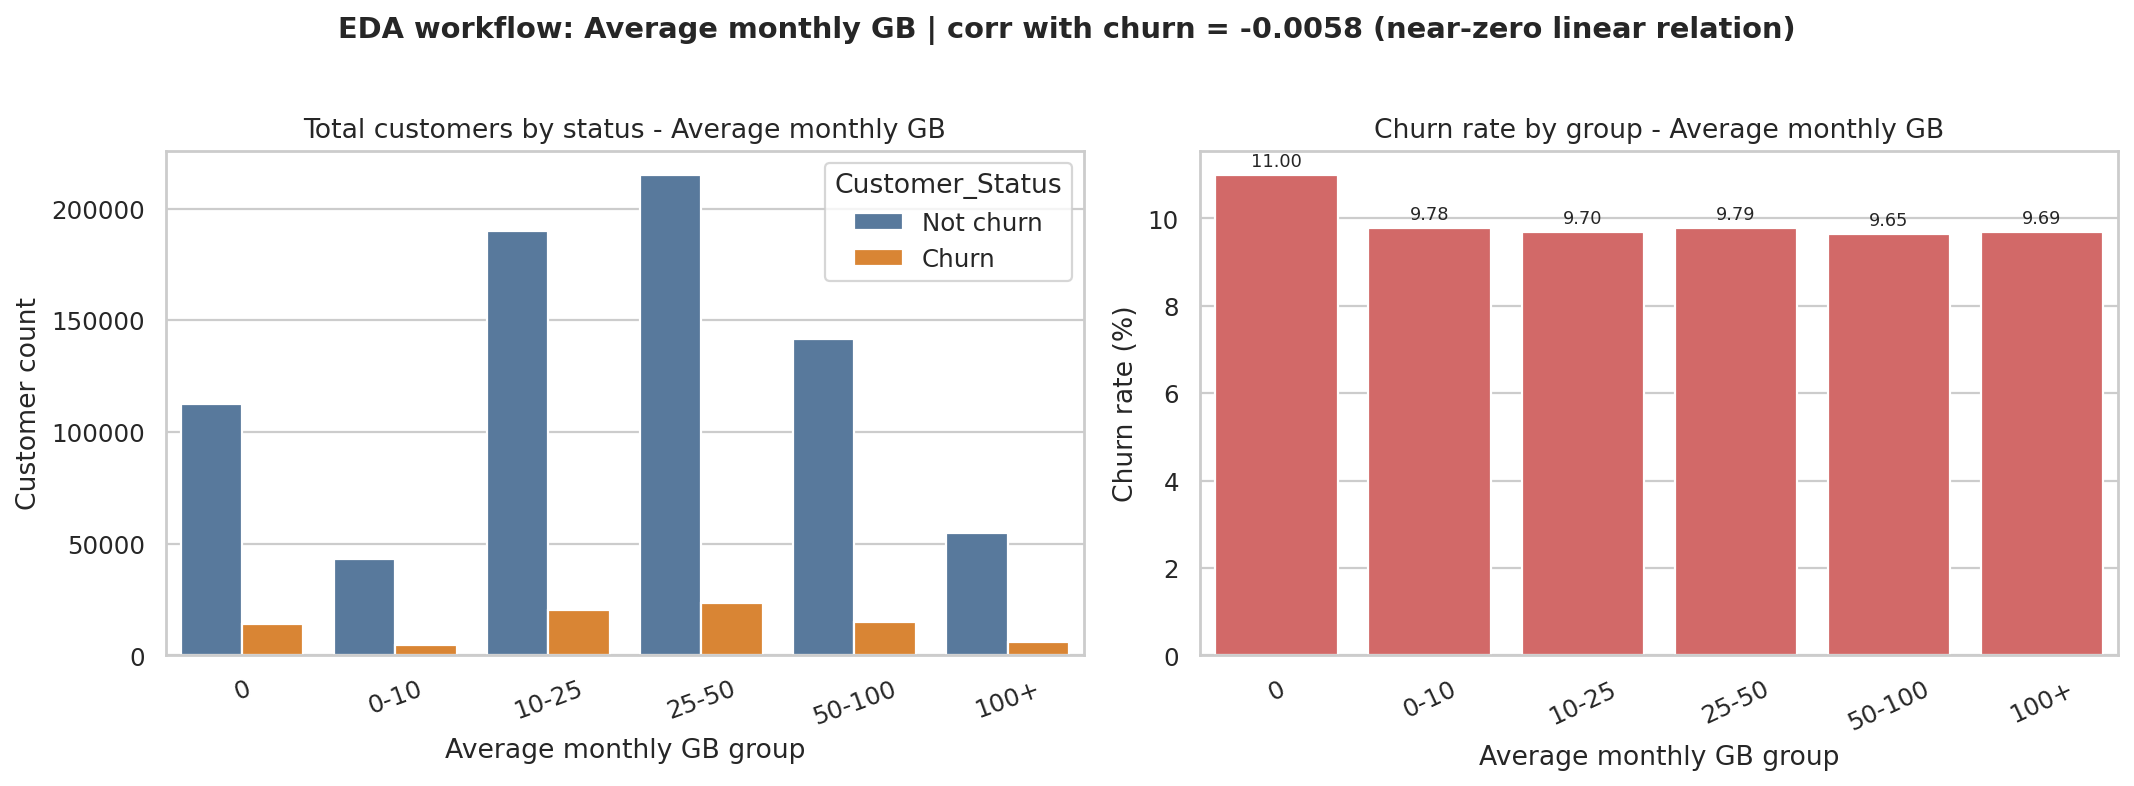

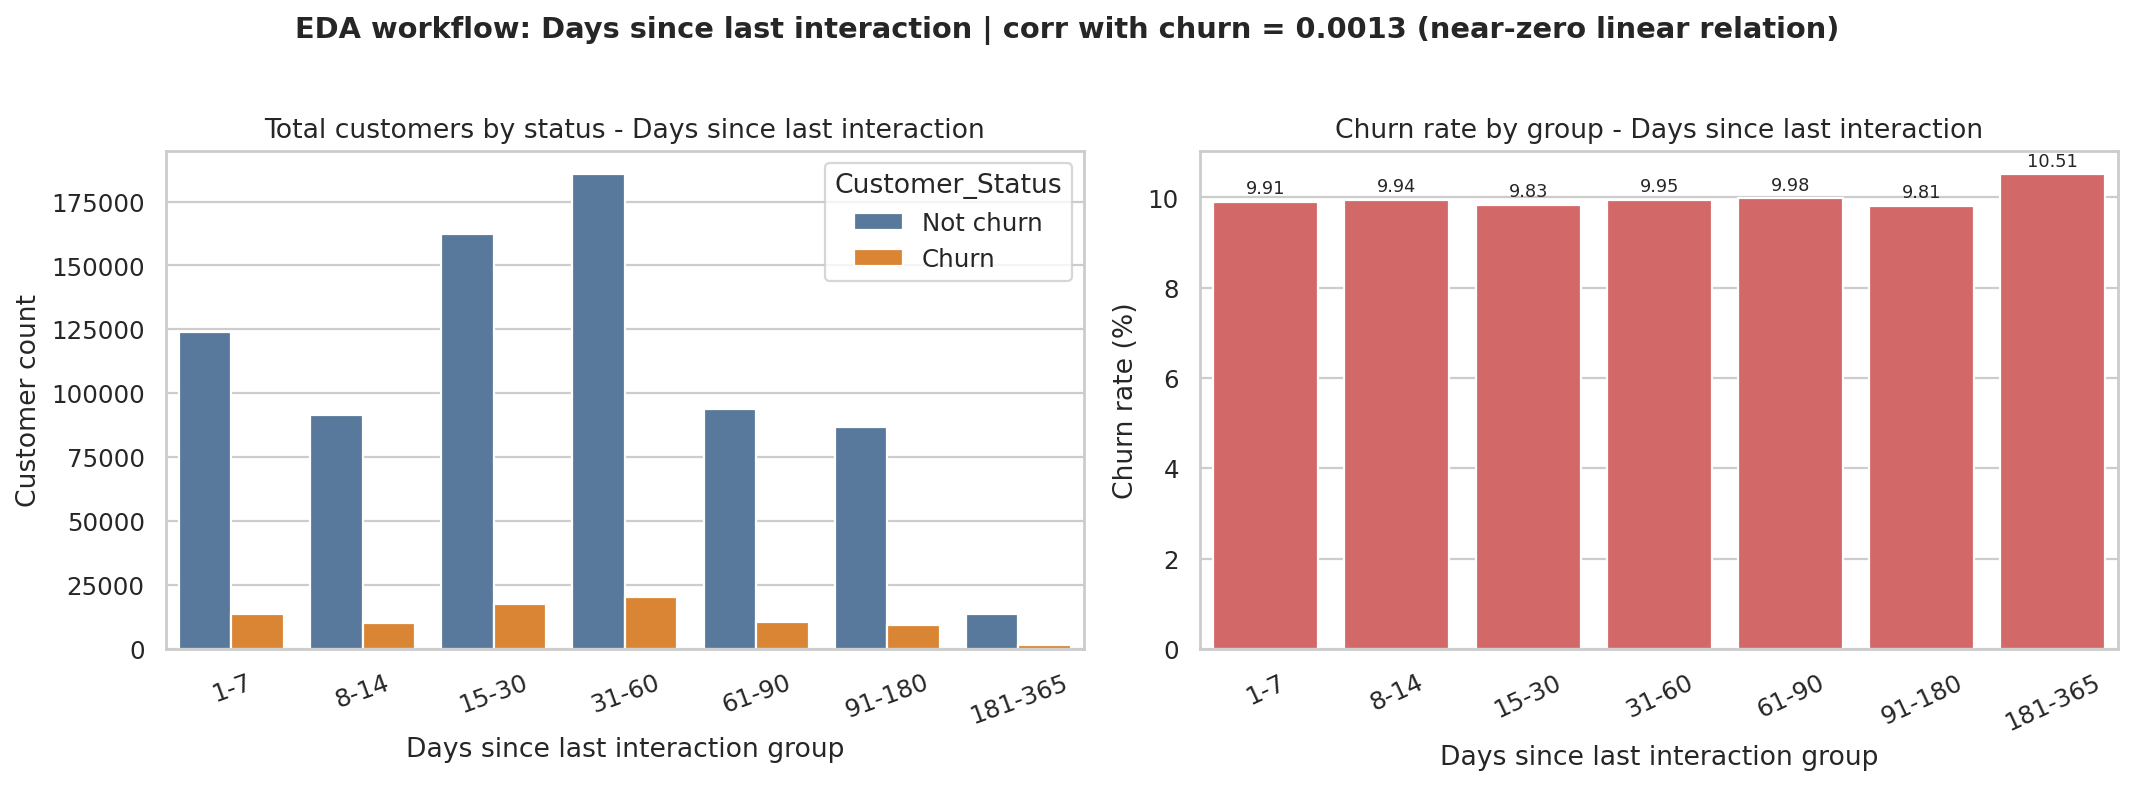

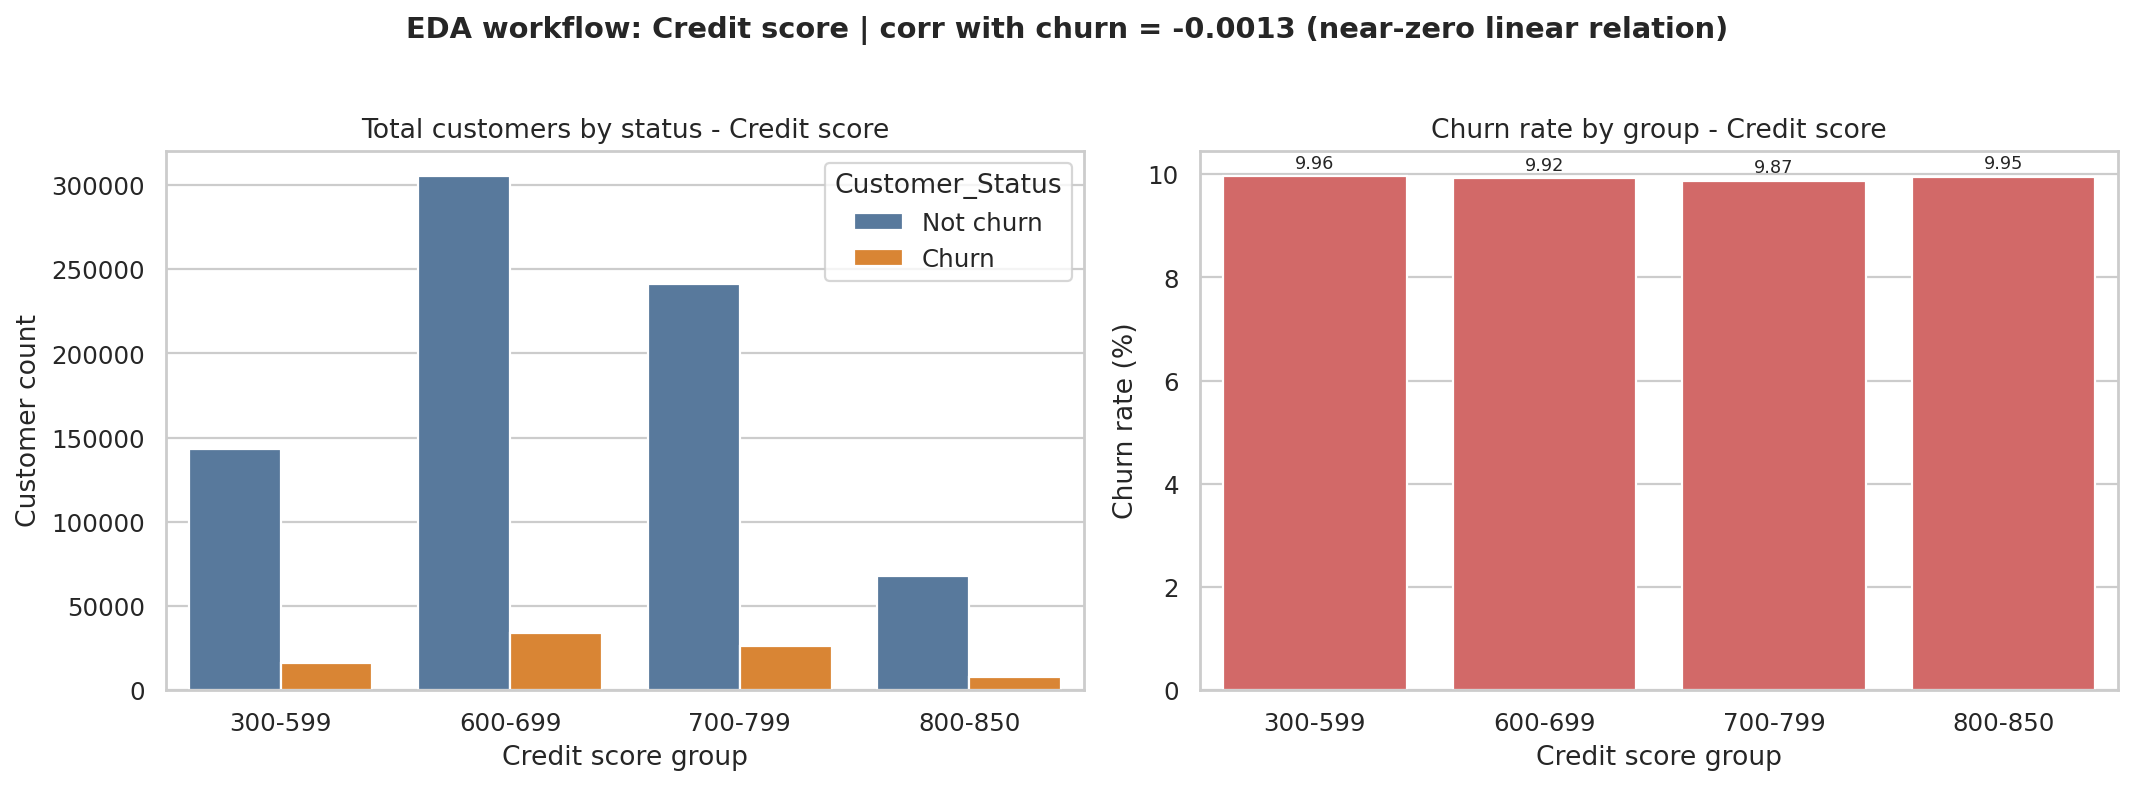

{'customer_satisfaction': PosixPath('/home/tung/2025.2-Data-Visualization/data vis/eda_outputs/customer_satisfaction_eda.png'),
 'num_complaints': PosixPath('/home/tung/2025.2-Data-Visualization/data vis/eda_outputs/num_complaints_eda.png'),
 'num_service_calls': PosixPath('/home/tung/2025.2-Data-Visualization/data vis/eda_outputs/num_service_calls_eda.png'),
 'late_payments': PosixPath('/home/tung/2025.2-Data-Visualization/data vis/eda_outputs/late_payments_eda.png'),
 'avg_monthly_gb': PosixPath('/home/tung/2025.2-Data-Visualization/data vis/eda_outputs/avg_monthly_gb_eda.png'),
 'days_since_last_interaction': PosixPath('/home/tung/2025.2-Data-Visualization/data vis/eda_outputs/days_since_last_interaction_eda.png'),
 'credit_score': PosixPath('/home/tung/2025.2-Data-Visualization/data vis/eda_outputs/credit_score_eda.png')}

In [4]:
plot_paths = {}
status_colors = {"Not churn": "#4c78a8", "Churn": "#f58518"}
rate_color = "#e45756"

for feature, cfg in FEATURE_CONFIG.items():
    group_col = f"{feature}_group"
    labels = cfg["labels"]
    counts = (
        df.groupby([group_col, "Customer_Status"], observed=False)
        .size()
        .rename("count")
        .reset_index()
    )
    counts[group_col] = pd.Categorical(counts[group_col], categories=labels, ordered=True)
    table = group_tables[feature].reset_index().rename(columns={group_col: "Group"})
    table["Group"] = pd.Categorical(table["Group"], categories=labels, ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), dpi=160)

    sns.barplot(
        data=counts,
        x=group_col,
        y="count",
        hue="Customer_Status",
        hue_order=["Not churn", "Churn"],
        palette=status_colors,
        ax=axes[0],
    )
    axes[0].set_title(f"Total customers by status - {cfg['title']}")
    axes[0].set_xlabel(cfg["xlabel"])
    axes[0].set_ylabel("Customer count")
    axes[0].tick_params(axis="x", rotation=20 if len(labels) > 5 else 0)

    sns.barplot(
        data=table,
        x="Group",
        y="Churn rate (%)",
        color=rate_color,
        ax=axes[1],
    )
    axes[1].bar_label(axes[1].containers[0], fmt="%.2f", fontsize=8, padding=2)
    axes[1].set_title(f"Churn rate by group - {cfg['title']}")
    axes[1].set_xlabel(cfg["xlabel"])
    axes[1].set_ylabel("Churn rate (%)")
    axes[1].tick_params(axis="x", rotation=25 if len(labels) > 5 else 0)

    corr = corr_with_churn[feature]
    direction = "higher values lean Churn" if corr > 0.01 else "higher values lean Not churn" if corr < -0.01 else "near-zero linear relation"
    fig.suptitle(
        f"EDA workflow: {cfg['title']} | corr with churn = {corr:.4f} ({direction})",
        y=1.02,
        fontsize=13,
        fontweight="bold",
    )
    fig.tight_layout()
    out = OUTPUT_DIR / f"{feature}_eda.png"
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    plot_paths[feature] = out

plot_paths

In [5]:
def fmt_num(x, decimals=2):
    if pd.isna(x):
        return "NA"
    if float(x).is_integer():
        return f"{int(x):,}"
    return f"{x:,.{decimals}f}"

def corr_label(corr: float) -> str:
    if abs(corr) < 0.01:
        return "gần như không có tương quan tuyến tính với churn"
    if corr > 0:
        return "tương quan dương: giá trị cao hơn nghiêng về Churn"
    return "tương quan âm: giá trị cao hơn nghiêng về Not churn"

def stats_text(feature: str) -> str:
    stats = segment_stats[feature]
    ch = stats.loc["Churn"]
    st = stats.loc["Not churn"]
    corr = corr_with_churn[feature]
    table = group_tables[feature]

    lines = [
        "EDA riêng theo churn/not churn:",
        f"Churn: n={fmt_num(ch['count'],0)}, mean={fmt_num(ch['mean'])}, median={fmt_num(ch['50%'])}, p75={fmt_num(ch['75%'])}, max={fmt_num(ch['max'])}",
        f"Not churn: n={fmt_num(st['count'],0)}, mean={fmt_num(st['mean'])}, median={fmt_num(st['50%'])}, p75={fmt_num(st['75%'])}, max={fmt_num(st['max'])}",
        f"Corr với churn: r={corr:.4f} ({corr_label(corr)})",
        "",
        "Bảng theo nhóm giống workflow Power BI:",
        "Group | Not churn | Churn | Total | Churn rate",
    ]
    for idx, row in table.iterrows():
        lines.append(
            f"{idx}: {int(row['Not churn']):,} | {int(row['Churn']):,} | {int(row['Total']):,} | {row['Churn rate (%)']:.2f}%"
        )
    return "\n".join(lines)

insights = {
    "customer_satisfaction": (
        "Feature này nghiêng về Not churn khi giá trị tăng: r=-0.0846. Nhóm satisfaction thấp 1-3 có churn rate 15.46%, "
        "trong khi nhóm cao 7-9 chỉ 8.05%. Đây là tín hiệu mạnh nhất trong nhóm feature của Tùng: điểm hài lòng thấp là dấu hiệu rủi ro churn rõ ràng."
    ),
    "num_complaints": (
        "Feature này nghiêng về Churn khi giá trị tăng: r=0.0802. Churn rate tăng từ 8.08% ở nhóm không complaint lên 18.46% ở nhóm 3+ complaint. "
        "Complaint count là tín hiệu hành vi quan trọng; khách có nhiều complaint nên được ưu tiên retention/support."
    ),
    "num_service_calls": (
        "Feature này cũng nghiêng về Churn: r=0.0771. Churn rate tăng đều từ 7.72% khi không có service call lên 17.51% ở nhóm 5+ calls. "
        "Nhiều service calls có thể phản ánh sự cố hoặc trải nghiệm kém, nên là biến cảnh báo gần tương đương num_complaints."
    ),
    "late_payments": (
        "Feature này có tương quan dương vừa phải với churn: r=0.0481. Churn rate tăng từ 9.05% khi không late payment lên 17.39% ở nhóm 3+. "
        "Late payment không mạnh bằng satisfaction/complaints/service calls nhưng vẫn là chỉ báo sớm cho nhóm khách rủi ro."
    ),
    "avg_monthly_gb": (
        "Feature này gần như không phân tách churn/not churn: r=-0.0059. Ngoài nhóm 0 GB có churn rate 11.00%, các nhóm còn lại dao động rất hẹp quanh 9.65-9.79%. "
        "Do đó avg_monthly_gb không nên xem là driver chính nếu đứng một mình."
    ),
    "days_since_last_interaction": (
        "Feature này gần như không có tương quan tuyến tính với churn: r=0.0013. Các nhóm thời gian đều quanh 9.81-10.51% churn rate. "
        "Biến này một mình yếu, nhưng có thể hữu ích khi kết hợp với complaint, satisfaction hoặc service calls."
    ),
    "credit_score": (
        "Feature này gần như không phân tách churn/not churn: r=-0.0013. Churn rate theo nhóm credit score dao động rất nhỏ, khoảng 9.87-9.96%. "
        "Credit score không phải tín hiệu churn đáng kể trong bộ dữ liệu này."
    ),
}

excel_rows = {
    "customer_satisfaction": 10,
    "num_complaints": 11,
    "num_service_calls": 12,
    "late_payments": 13,
    "avg_monthly_gb": 14,
    "days_since_last_interaction": 15,
    "credit_score": 16,
}

excel_payload = {
    feature: {
        "row": row,
        "stats": stats_text(feature),
        "insight": insights[feature],
        "plot_path": str(plot_paths[feature]),
    }
    for feature, row in excel_rows.items()
}

for feature, payload in excel_payload.items():
    print("\n" + "=" * 96)
    print(feature)
    print(payload["stats"])
    print("Insight:", payload["insight"])
    print("Plot:", payload["plot_path"])


customer_satisfaction
EDA riêng theo churn/not churn:
Churn: n=83,362, mean=5.57, median=6, p75=8, max=9
Not churn: n=757,403, mean=6.22, median=7, p75=8, max=9
Corr với churn: r=-0.0846 (tương quan âm: giá trị cao hơn nghiêng về Not churn)

Bảng theo nhóm giống workflow Power BI:
Group | Not churn | Churn | Total | Churn rate
Low 1-3: 113,885 | 20,820 | 134,705 | 15.46%
Medium 4-6: 249,370 | 28,040 | 277,410 | 10.11%
High 7-9: 394,148 | 34,502 | 428,650 | 8.05%
Insight: Feature này nghiêng về Not churn khi giá trị tăng: r=-0.0846. Nhóm satisfaction thấp 1-3 có churn rate 15.46%, trong khi nhóm cao 7-9 chỉ 8.05%. Đây là tín hiệu mạnh nhất trong nhóm feature của Tùng: điểm hài lòng thấp là dấu hiệu rủi ro churn rõ ràng.
Plot: /home/tung/2025.2-Data-Visualization/data vis/eda_outputs/customer_satisfaction_eda.png

num_complaints
EDA riêng theo churn/not churn:
Churn: n=83,362, mean=0.90, median=1, p75=1, max=7
Not churn: n=757,403, mean=0.68, median=0, p75=1, max=7
Corr với churn: r=0.0

In [6]:
from copy import copy

from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import Alignment

workbook_path = BASE / "DATA VISUALIZATION.xlsx"
wb = load_workbook(workbook_path)
ws = wb.active

# Find current MINH block. If it is still directly after old Tùng rows, insert rows
# so Tùng has 7 feature rows while preserving the later group section.
def find_value_in_col(value: str, col: int = 1):
    for row in range(1, ws.max_row + 1):
        cell_value = ws.cell(row, col).value
        if isinstance(cell_value, str) and cell_value.strip().upper() == value.upper():
            return row
    return None

def unmerge_if_overlaps(start_row: int, end_row: int, col: int = 1):
    for merge_range in list(ws.merged_cells.ranges):
        if merge_range.min_col <= col <= merge_range.max_col and not (
            merge_range.max_row < start_row or merge_range.min_row > end_row
        ):
            ws.unmerge_cells(str(merge_range))

def move_image_rows_from(start_row: int, amount: int):
    for img in ws._images:
        anchor = img.anchor
        if hasattr(anchor, "_from") and anchor._from.row + 1 >= start_row:
            anchor._from.row += amount
            if hasattr(anchor, "_to") and anchor._to is not None:
                anchor._to.row += amount

minh_row = find_value_in_col("MINH")
if minh_row is not None and minh_row < 17:
    shift = 17 - minh_row
    unmerge_if_overlaps(10, 20, col=1)
    move_image_rows_from(minh_row, shift)
    ws.insert_rows(minh_row, amount=shift)

# Remove old Tùng images before adding the regenerated plots. This makes reruns idempotent.
tung_rows = set(range(10, 17))
kept_images = []
for img in ws._images:
    anchor = img.anchor
    if hasattr(anchor, "_from"):
        row = anchor._from.row + 1
        col = anchor._from.col + 1
        if col == 4 and row in tung_rows:
            continue
    kept_images.append(img)
ws._images = kept_images

unmerge_if_overlaps(10, 20, col=1)
ws.merge_cells("A10:A16")
ws["A10"] = "TÙNG"
if find_value_in_col("MINH") is not None:
    ws.merge_cells("A17:A20")
    ws["A17"] = "MINH"

# Use a consistent style source for the expanded Tùng block.
style_source = ws["B10"] if ws["B10"].style_id != 0 else ws["B13"]
for row in range(10, 17):
    for col in "BCDE":
        cell = ws[f"{col}{row}"]
        cell.value = None
        cell._style = copy(style_source._style)
        cell.alignment = Alignment(wrap_text=True, vertical="top")

for feature, payload in excel_payload.items():
    row = payload["row"]
    ws[f"B{row}"] = feature
    ws[f"C{row}"] = payload["stats"]
    ws[f"E{row}"] = payload["insight"]

    for col in "BCDE":
        ws[f"{col}{row}"].alignment = Alignment(wrap_text=True, vertical="top")

    plot = XLImage(payload["plot_path"])
    plot.width = 330
    plot.height = 117
    plot.anchor = f"D{row}"
    ws.add_image(plot)
    ws.row_dimensions[row].height = 102

ws.column_dimensions["B"].width = 28
ws.column_dimensions["C"].width = 55
ws.column_dimensions["D"].width = 48
ws.column_dimensions["E"].width = 106.75

wb.save(workbook_path)
print(f"Updated workbook: {workbook_path}")

Updated workbook: /home/tung/2025.2-Data-Visualization/data vis/DATA VISUALIZATION.xlsx
